<a href="https://www.kaggle.com/code/miraalhalabi/classification-titanic?scriptVersionId=315395849" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

## Titanic: Machine Learning from Disaster (Kaggle Dataset)

**Algorithms Covered:**
- Logistic Regression
- K-Nearest Neighbors (KNN)
- Support Vector Classifier (SVC)
- Naïve Bayes

**Goal:** Predict which passengers survived the Titanic disaster.

---

## 📦 Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# --- Scikit-learn imports ---
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📊 Step 2: Load & Explore the Titanic Dataset

You can download the dataset from Kaggle:
- https://www.kaggle.com/competitions/titanic/data

Or use the version built into seaborn:

In [2]:
# Load Titanic dataset (built into seaborn — no Kaggle account needed)
df = sns.load_dataset('titanic')

print('Dataset shape:', df.shape)
print('\n--- First 5 rows ---')
df.head()

Dataset shape: (891, 15)

--- First 5 rows ---


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Basic info
print('--- Dataset Info ---')
df.info()

print('\n--- Missing Values ---')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}).query('`Missing Count` > 0'))

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

--- Missing Values ---
             Missing Count  Missin

In [4]:
# Survival statistics
print('--- Survival Distribution ---')
print(df['survived'].value_counts())
print(f'\nSurvival Rate: {df["survived"].mean():.2%}')

--- Survival Distribution ---
survived
0    549
1    342
Name: count, dtype: int64

Survival Rate: 38.38%


## 📈 Step 3: Exploratory Data Analysis (EDA)

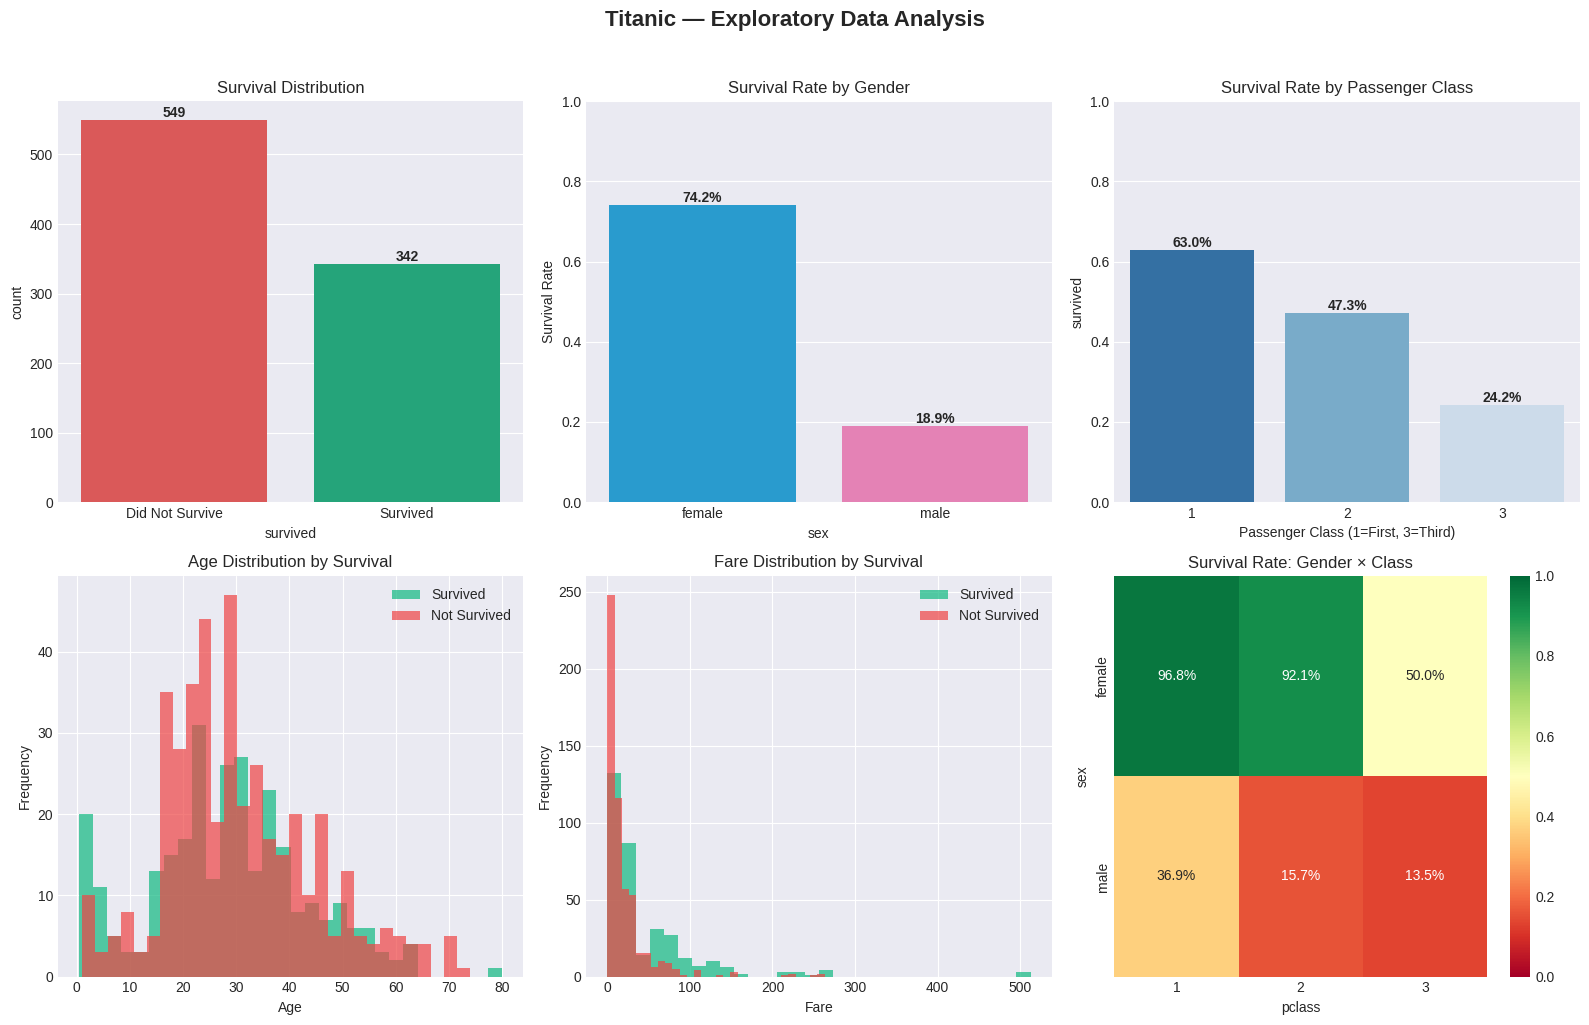

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Titanic — Exploratory Data Analysis', fontsize=16, fontweight='bold', y=1.02)

# 1. Survival count
sns.countplot(data=df, x='survived', palette=['#EF4444', '#10B981'], ax=axes[0, 0])
axes[0, 0].set_title('Survival Distribution')
axes[0, 0].set_xticklabels(['Did Not Survive', 'Survived'])
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                        ha='center', va='bottom', fontweight='bold')

# 2. Survival by Gender
gender_survival = df.groupby('sex')['survived'].mean().reset_index()
sns.barplot(data=gender_survival, x='sex', y='survived', palette=['#0EA5E9', '#F472B6'], ax=axes[0, 1])
axes[0, 1].set_title('Survival Rate by Gender')
axes[0, 1].set_ylabel('Survival Rate')
axes[0, 1].set_ylim(0, 1)
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f'{p.get_height():.1%}', (p.get_x() + p.get_width()/2., p.get_height()),
                        ha='center', va='bottom', fontweight='bold')

# 3. Survival by Passenger Class
pclass_survival = df.groupby('pclass')['survived'].mean().reset_index()
sns.barplot(data=pclass_survival, x='pclass', y='survived', palette='Blues_r', ax=axes[0, 2])
axes[0, 2].set_title('Survival Rate by Passenger Class')
axes[0, 2].set_xlabel('Passenger Class (1=First, 3=Third)')
axes[0, 2].set_ylim(0, 1)
for p in axes[0, 2].patches:
    axes[0, 2].annotate(f'{p.get_height():.1%}', (p.get_x() + p.get_width()/2., p.get_height()),
                        ha='center', va='bottom', fontweight='bold')

# 4. Age distribution
df[df['survived'] == 1]['age'].plot(kind='hist', bins=30, alpha=0.7, label='Survived', color='#10B981', ax=axes[1, 0])
df[df['survived'] == 0]['age'].plot(kind='hist', bins=30, alpha=0.7, label='Not Survived', color='#EF4444', ax=axes[1, 0])
axes[1, 0].set_title('Age Distribution by Survival')
axes[1, 0].set_xlabel('Age')
axes[1, 0].legend()

# 5. Fare distribution (log scale)
df[df['survived'] == 1]['fare'].plot(kind='hist', bins=30, alpha=0.7, label='Survived', color='#10B981', ax=axes[1, 1])
df[df['survived'] == 0]['fare'].plot(kind='hist', bins=30, alpha=0.7, label='Not Survived', color='#EF4444', ax=axes[1, 1])
axes[1, 1].set_title('Fare Distribution by Survival')
axes[1, 1].set_xlabel('Fare')
axes[1, 1].legend()

# 6. Heatmap of survival by gender & class
pivot = df.pivot_table(values='survived', index='sex', columns='pclass', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.1%', cmap='RdYlGn', ax=axes[1, 2], vmin=0, vmax=1)
axes[1, 2].set_title('Survival Rate: Gender × Class')

plt.tight_layout()
plt.show()

In [6]:
def evaluate_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'  {name:<35}  MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}')
    return {'Model': name, 'MAE': round(mae, 4), 'RMSE': round(rmse, 4), 'R2': round(r2, 4)}

all_results = []
all_preds   = {}
print('Helper function ready!')

Helper function ready!


## 🔧 Step 4: Feature Engineering & Preprocessing

In [7]:
# Work on a copy
data = df.copy()

# ── 4.1  Handle Missing Values ──────────────────────────────────────────────

# Age: fill with median by passenger class
data['age'] = data.groupby('pclass')['age'].transform(lambda x: x.fillna(x.median()))

# Embarked: fill with mode (most common port)
data['embarked'] = data['embarked'].fillna(data['embarked'].mode()[0])

# Fare: fill with median
data['fare'] = data['fare'].fillna(data['fare'].median())

print('Missing values after imputation:')
print(data.isnull().sum()[data.isnull().sum() > 0])
print('✅ No missing values!' if data.isnull().sum().sum() == 0 else '')

Missing values after imputation:
deck           688
embark_town      2
dtype: int64



In [8]:
# ── 4.2  Feature Engineering ────────────────────────────────────────────────

# Family size feature
data['family_size'] = data['sibsp'] + data['parch'] + 1
data['is_alone'] = (data['family_size'] == 1).astype(int)

# Age groups
data['age_group'] = pd.cut(data['age'], bins=[0, 12, 18, 35, 60, 100],
                           labels=['child', 'teen', 'young_adult', 'adult', 'senior'])

# Fare per person
data['fare_per_person'] = data['fare'] / data['family_size']

print('New features created:')
print(data[['family_size', 'is_alone', 'age_group', 'fare_per_person']].head(10))

New features created:
   family_size  is_alone    age_group  fare_per_person
0            2         0  young_adult          3.62500
1            2         0        adult         35.64165
2            1         1  young_adult          7.92500
3            2         0  young_adult         26.55000
4            1         1  young_adult          8.05000
5            1         1  young_adult          8.45830
6            1         1        adult         51.86250
7            5         0        child          4.21500
8            3         0  young_adult          3.71110
9            2         0         teen         15.03540


In [9]:
# ── 4.3  Encode Categorical Variables ──────────────────────────────────────

# Binary encoding: sex
data['sex_encoded'] = (data['sex'] == 'male').astype(int)  # 1=male, 0=female

# One-hot encoding: embarked
embarked_dummies = pd.get_dummies(data['embarked'], prefix='embarked')
data = pd.concat([data, embarked_dummies], axis=1)

# Ordinal encoding: age_group
age_map = {'child': 0, 'teen': 1, 'young_adult': 2, 'adult': 3, 'senior': 4}
data['age_group_enc'] = data['age_group'].map(age_map)

# ── 4.4  Select Final Features ──────────────────────────────────────────────
features = [
    'pclass', 'sex_encoded', 'age', 'fare', 'family_size',
    'is_alone', 'fare_per_person', 'age_group_enc',
    'embarked_C', 'embarked_Q', 'embarked_S'
]

X = data[features]
y = data['survived']

print(f'Feature matrix shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'\nFeatures used: {features}')

Feature matrix shape: (891, 11)
Target shape: (891,)

Features used: ['pclass', 'sex_encoded', 'age', 'fare', 'family_size', 'is_alone', 'fare_per_person', 'age_group_enc', 'embarked_C', 'embarked_Q', 'embarked_S']


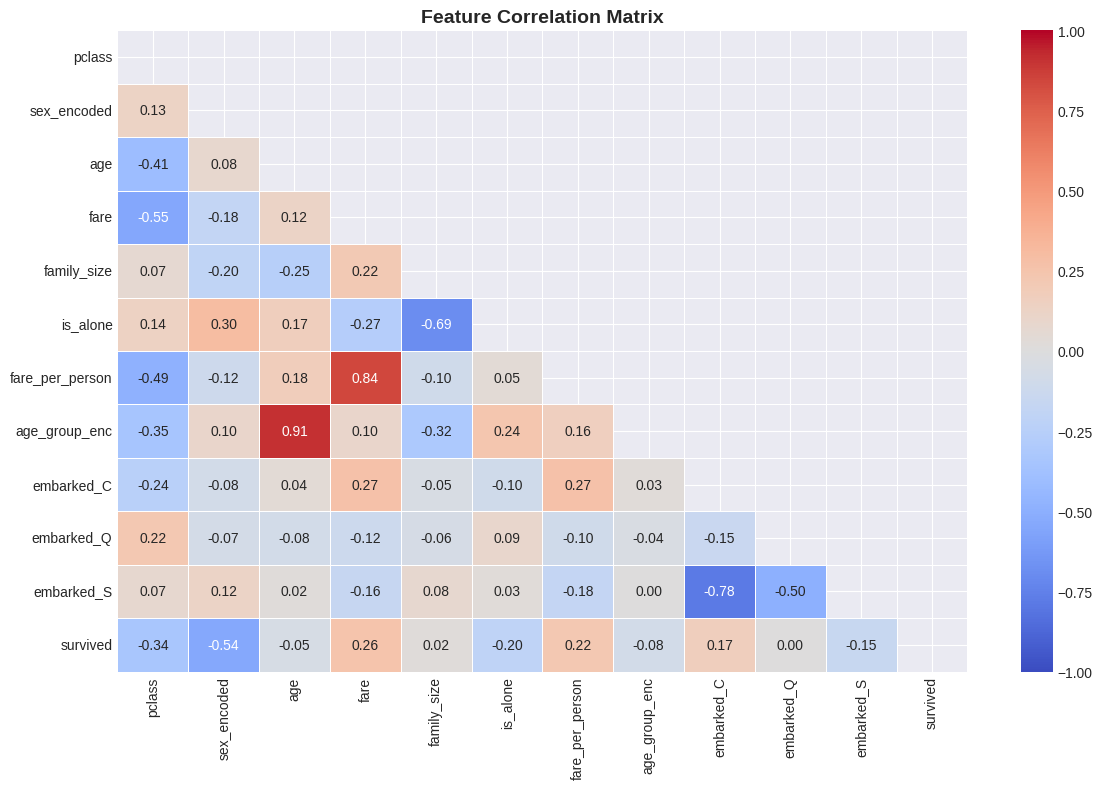

In [10]:
# Correlation heatmap of features
plt.figure(figsize=(12, 8))
correlation = X.join(y).corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))
sns.heatmap(correlation, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## ✂️ Step 5: Train-Test Split & Feature Scaling

In [11]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')
print(f'\nClass distribution in train: {y_train.value_counts().to_dict()}')
print(f'Class distribution in test:  {y_test.value_counts().to_dict()}')

# Feature scaling (required for LR, KNN, SVC)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('\n✅ Data split and scaled!')

Training set: 712 samples
Test set:     179 samples

Class distribution in train: {0: 439, 1: 273}
Class distribution in test:  {0: 110, 1: 69}

✅ Data split and scaled!


## 🤖 Step 6: Train All Four Classification Models

### 6.1 Logistic Regression

In [12]:
# ── Logistic Regression ──────────────────────────────────────────────────────
lr = LogisticRegression(C=1.0, max_iter=500, random_state=42)
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]

print('=== Logistic Regression ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_lr):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_lr):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred_lr):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, y_prob_lr):.4f}')

# Feature importance (coefficients)
coef_df = pd.DataFrame({'feature': features, 'coefficient': lr.coef_[0]})
coef_df = coef_df.sort_values('coefficient', key=abs, ascending=False)
print('\nTop features by |coefficient|:')
print(coef_df.head(6).to_string(index=False))
# added to know the mistakes for every classifcation and compare between them
res_logastic = evaluate_model(f'Logastic  ',y_test, y_pred_lr)
all_results.append(res_logastic)

=== Logistic Regression ===
Accuracy:  0.7989
Precision: 0.7619
Recall:    0.6957
F1-Score:  0.7273
ROC-AUC:   0.8491

Top features by |coefficient|:
      feature  coefficient
  sex_encoded    -1.248830
       pclass    -0.960606
  family_size    -0.519901
age_group_enc    -0.442846
     is_alone    -0.278162
          age    -0.135211
  Logastic                             MAE=0.2011  RMSE=0.4485  R²=0.1510


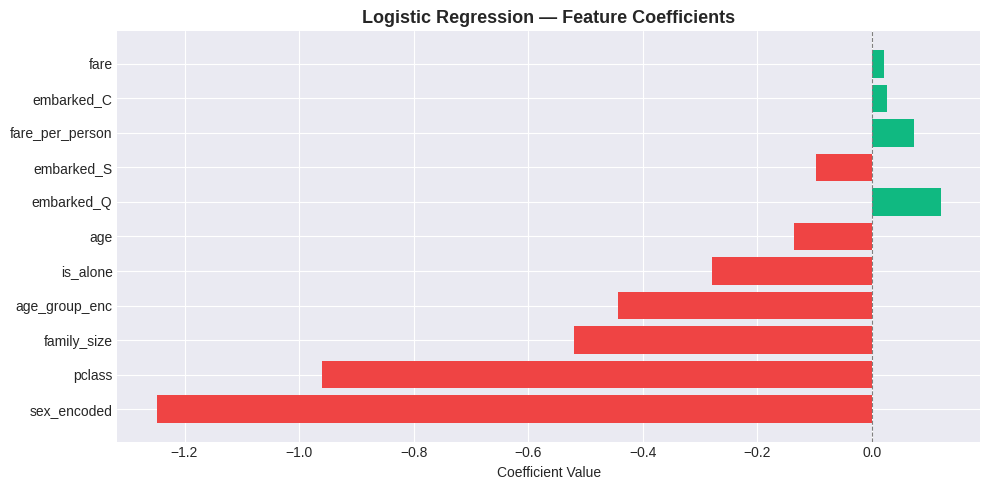

📌 Positive coefficient → increases P(survived). Negative → decreases it.


In [13]:
# Visualize coefficients
plt.figure(figsize=(10, 5))
colors = ['#10B981' if c > 0 else '#EF4444' for c in coef_df['coefficient']]
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
plt.axvline(x=0, color='gray', linestyle='--', linewidth=0.8)
plt.title('Logistic Regression — Feature Coefficients', fontsize=13, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()
print('📌 Positive coefficient → increases P(survived). Negative → decreases it.')

### 6.2 K-Nearest Neighbors (KNN)

Best K = 14 with test accuracy = 0.8268


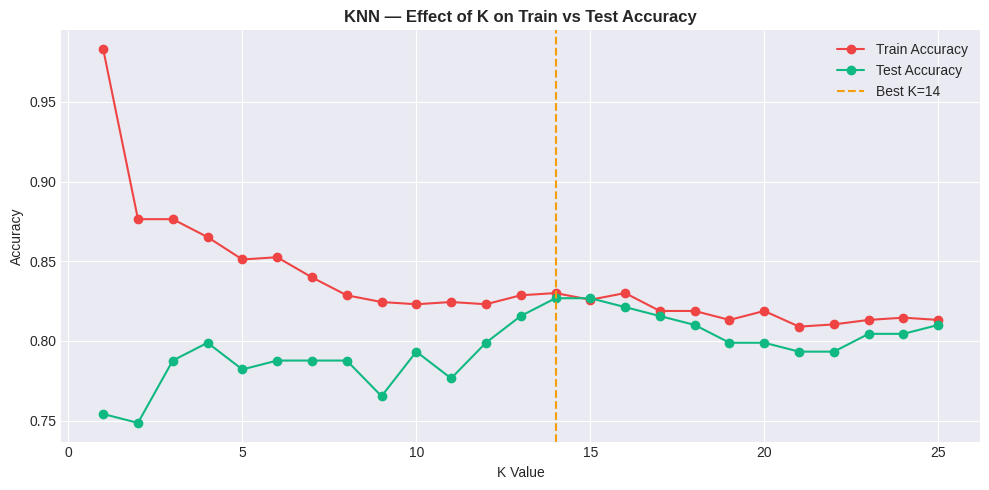

In [14]:
# ── Finding the best K ────────────────────────────────────────────────────────
k_range = range(1, 26)
train_scores, test_scores = [], []

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_sc, y_train)
    train_scores.append(knn_temp.score(X_train_sc, y_train))
    test_scores.append(knn_temp.score(X_test_sc, y_test))

best_k = k_range[np.argmax(test_scores)]
print(f'Best K = {best_k} with test accuracy = {max(test_scores):.4f}')

plt.figure(figsize=(10, 5))
plt.plot(k_range, train_scores, 'o-', label='Train Accuracy', color='#EF4444')
plt.plot(k_range, test_scores, 'o-', label='Test Accuracy', color='#10B981')
plt.axvline(x=best_k, color='#F59E0B', linestyle='--', label=f'Best K={best_k}')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('KNN — Effect of K on Train vs Test Accuracy', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# ── Train KNN with best K ─────────────────────────────────────────────────────
knn = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn.fit(X_train_sc, y_train)

y_pred_knn = knn.predict(X_test_sc)
y_prob_knn = knn.predict_proba(X_test_sc)[:, 1]

print(f'=== KNN (K={best_k}) ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_knn):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_knn):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_knn):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred_knn):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, y_prob_knn):.4f}')

res_knn = evaluate_model(f'knn  ',y_test, y_pred_knn)
all_results.append(res_knn)

=== KNN (K=14) ===
Accuracy:  0.8268
Precision: 0.8393
Recall:    0.6812
F1-Score:  0.7520
ROC-AUC:   0.8362
  knn                                  MAE=0.1732  RMSE=0.4162  R²=0.2689


### 6.3 Support Vector Classifier (SVC)

In [16]:
# ── SVC with RBF kernel ───────────────────────────────────────────────────────
svc = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svc.fit(X_train_sc, y_train)

y_pred_svc = svc.predict(X_test_sc)
y_prob_svc = svc.predict_proba(X_test_sc)[:, 1]

print('=== SVC (RBF Kernel) ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_svc):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_svc):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_svc):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred_svc):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, y_prob_svc):.4f}')
print(f'\nNumber of support vectors per class: {svc.n_support_}')

res_svc = evaluate_model(f'SVC  ',y_test, y_pred_lr)
all_results.append(res_svc)

=== SVC (RBF Kernel) ===
Accuracy:  0.8156
Precision: 0.8333
Recall:    0.6522
F1-Score:  0.7317
ROC-AUC:   0.8404

Number of support vectors per class: [171 166]
  SVC                                  MAE=0.2011  RMSE=0.4485  R²=0.1510


In [17]:
# ── Hyperparameter Tuning with GridSearchCV ────────────────────────────────────
print('Tuning SVC hyperparameters... (this may take ~30 seconds)')

param_grid = {
    'C':      [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma':  ['scale', 'auto']
}

grid_svc = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
grid_svc.fit(X_train_sc, y_train)

print(f'Best parameters: {grid_svc.best_params_}')
print(f'Best CV F1-score: {grid_svc.best_score_:.4f}')

# Retrain with best params
best_svc = grid_svc.best_estimator_
y_pred_svc_tuned = best_svc.predict(X_test_sc)
y_prob_svc_tuned = best_svc.predict_proba(X_test_sc)[:, 1]
print(f'\nTuned SVC Test F1: {f1_score(y_test, y_pred_svc_tuned):.4f}')

Tuning SVC hyperparameters... (this may take ~30 seconds)
Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV F1-score: 0.7553

Tuned SVC Test F1: 0.6935


### 6.4 Naïve Bayes

In [18]:
# ── Gaussian Naïve Bayes ─────────────────────────────────────────────────────
# Note: GaussianNB doesn't need scaled features, but we use them for consistency
gnb = GaussianNB()
gnb.fit(X_train_sc, y_train)

y_pred_gnb = gnb.predict(X_test_sc)
y_prob_gnb = gnb.predict_proba(X_test_sc)[:, 1]

print('=== Gaussian Naïve Bayes ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_gnb):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_gnb):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_gnb):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred_gnb):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, y_prob_gnb):.4f}')

res_naiive = evaluate_model(f'Naiive Bayes  ',y_test, y_pred_lr)
all_results.append(res_naiive)

=== Gaussian Naïve Bayes ===
Accuracy:  0.7263
Precision: 0.7174
Recall:    0.4783
F1-Score:  0.5739
ROC-AUC:   0.8059
  Naiive Bayes                         MAE=0.2011  RMSE=0.4485  R²=0.1510


In [19]:
# Naïve Bayes class distributions (what the model learned)
print('Class Priors (P(class)):')
for i, c in enumerate(gnb.classes_):
    print(f'  P(survived={c}) = {gnb.class_prior_[i]:.4f}')

print('\nLearned feature means per class:')
means_df = pd.DataFrame(
    gnb.theta_, columns=features, index=['Not Survived (0)', 'Survived (1)']
).round(3)
print(means_df.T)

Class Priors (P(class)):
  P(survived=0) = 0.6166
  P(survived=1) = 0.3834

Learned feature means per class:
                 Not Survived (0)  Survived (1)
pclass                      0.274        -0.441
sex_encoded                 0.433        -0.696
age                         0.043        -0.070
fare                       -0.217         0.349
family_size                -0.021         0.034
is_alone                    0.170        -0.273
fare_per_person            -0.175         0.281
age_group_enc               0.068        -0.110
embarked_C                 -0.142         0.228
embarked_Q                 -0.025         0.040
embarked_S                  0.141        -0.227


## 📊 Step 7: Model Evaluation & Comparison

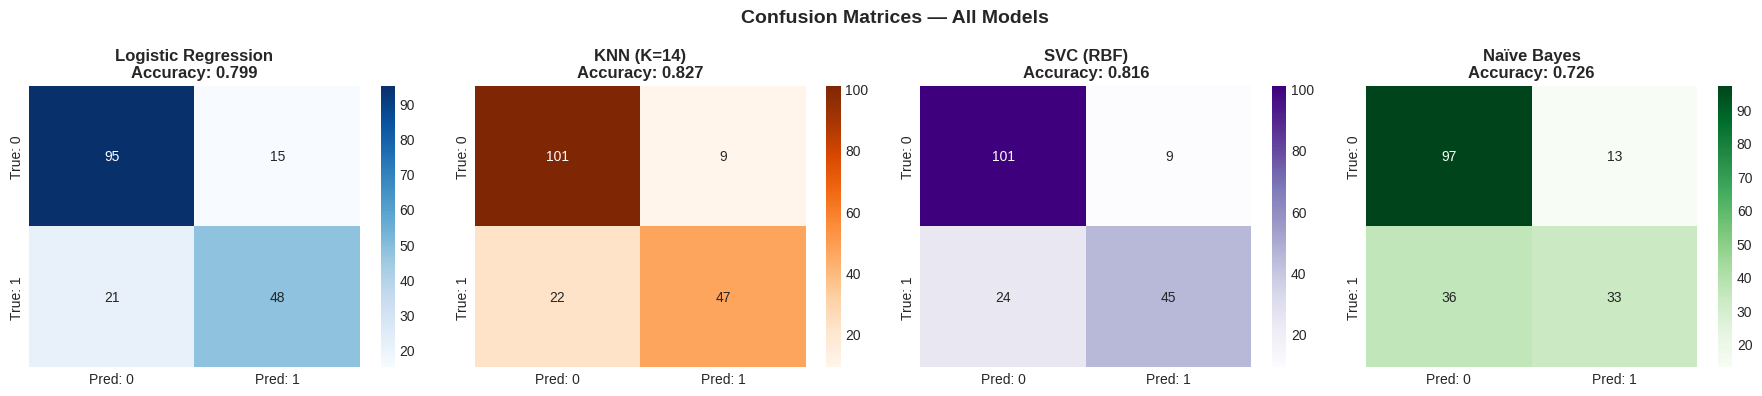

In [20]:
# ── Confusion Matrices for all 4 models ──────────────────────────────────────
models_info = [
    ('Logistic Regression', y_pred_lr),
    (f'KNN (K={best_k})',   y_pred_knn),
    ('SVC (RBF)',           y_pred_svc),
    ('Naïve Bayes',         y_pred_gnb),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')

colors = ['Blues', 'Oranges', 'Purples', 'Greens']
for ax, (name, preds), cmap in zip(axes, models_info, colors):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Pred: 0', 'Pred: 1'],
                yticklabels=['True: 0', 'True: 1'])
    acc = accuracy_score(y_test, preds)
    ax.set_title(f'{name}\nAccuracy: {acc:.3f}', fontweight='bold')

plt.tight_layout()
plt.show()

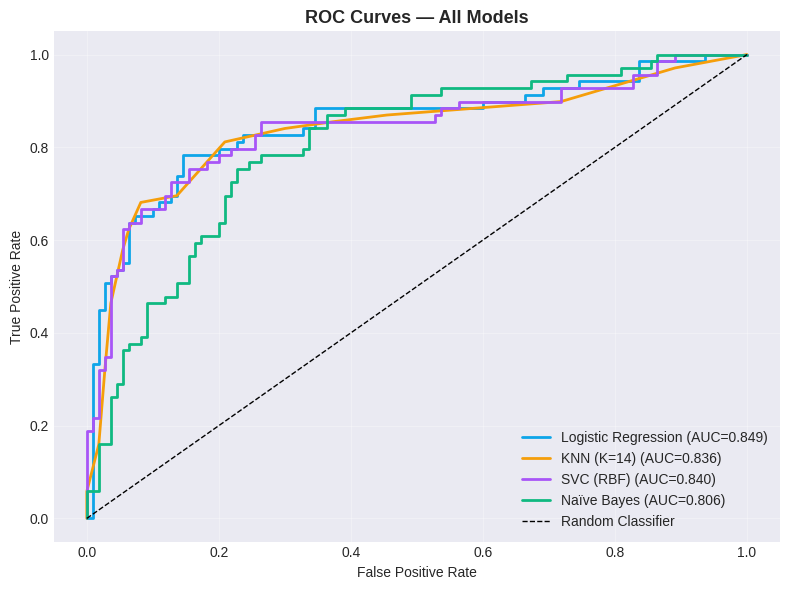

In [21]:
# ── ROC Curves ───────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 6))

models_roc = [
    ('Logistic Regression', y_prob_lr,  '#0EA5E9'),
    (f'KNN (K={best_k})',   y_prob_knn, '#F59E0B'),
    ('SVC (RBF)',           y_prob_svc, '#A855F7'),
    ('Naïve Bayes',         y_prob_gnb, '#10B981'),
]

for name, probs, color in models_roc:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
# ── Full Metrics Comparison Table ────────────────────────────────────────────
results = []

all_models = [
    ('Logistic Regression', y_pred_lr,  y_prob_lr),
    (f'KNN (K={best_k})',   y_pred_knn, y_prob_knn),
    ('SVC (RBF)',           y_pred_svc, y_prob_svc),
    ('Naïve Bayes',         y_pred_gnb, y_prob_gnb),
]

for name, preds, probs in all_models:
    cv_scores = cross_val_score(
        LogisticRegression(max_iter=500) if 'Logistic' in name else
        KNeighborsClassifier(n_neighbors=best_k) if 'KNN' in name else
        SVC(kernel='rbf', probability=True) if 'SVC' in name else
        GaussianNB(),
        X_train_sc, y_train, cv=5, scoring='accuracy'
    )
    results.append({
        'Model':      name,
        'Accuracy':   round(accuracy_score(y_test, preds),  4),
        'Precision':  round(precision_score(y_test, preds), 4),
        'Recall':     round(recall_score(y_test, preds),    4),
        'F1-Score':   round(f1_score(y_test, preds),        4),
        'ROC-AUC':    round(roc_auc_score(y_test, probs),   4),
        'CV Mean':    round(cv_scores.mean(),               4),
        'CV Std':     round(cv_scores.std(),                4),
    })

results_df = pd.DataFrame(results).set_index('Model')

# Highlight best values
styled = results_df.style.highlight_max(axis=0, props='background-color: #10B981; color: white; font-weight: bold;')
print('\n=== Model Comparison Summary ===')
print(results_df.to_string())
styled


=== Model Comparison Summary ===
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC  CV Mean  CV Std
Model                                                                               
Logistic Regression    0.7989     0.7619  0.6957    0.7273   0.8491   0.7979  0.0384
KNN (K=14)             0.8268     0.8393  0.6812    0.7520   0.8362   0.8091  0.0267
SVC (RBF)              0.8156     0.8333  0.6522    0.7317   0.8404   0.8217  0.0158
Naïve Bayes            0.7263     0.7174  0.4783    0.5739   0.8059   0.7599  0.0295


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV Mean,CV Std
Model,,,,,,,
Logistic Regression,0.798900,0.761900,0.695700,0.727300,0.849100,0.797900,0.038400
KNN (K=14),0.826800,0.839300,0.681200,0.752000,0.836200,0.809100,0.026700
SVC (RBF),0.815600,0.833300,0.652200,0.731700,0.840400,0.821700,0.015800
Naïve Bayes,0.726300,0.717400,0.478300,0.573900,0.805900,0.759900,0.029500


In [23]:
df_results = pd.DataFrame(all_results).sort_values('R2', ascending=False).reset_index(drop=True)

print('=' * 65)
print(df_results.to_string(index=False))
print('=' * 65)

best_name = df_results.iloc[0]['Model']

print(f'\nBest model: {best_name}  (R² = {df_results.iloc[0]["R2"]:.4f})')

         Model    MAE   RMSE     R2
         knn   0.1732 0.4162 0.2689
    Logastic   0.2011 0.4485 0.1510
         SVC   0.2011 0.4485 0.1510
Naiive Bayes   0.2011 0.4485 0.1510

Best model: knn    (R² = 0.2689)


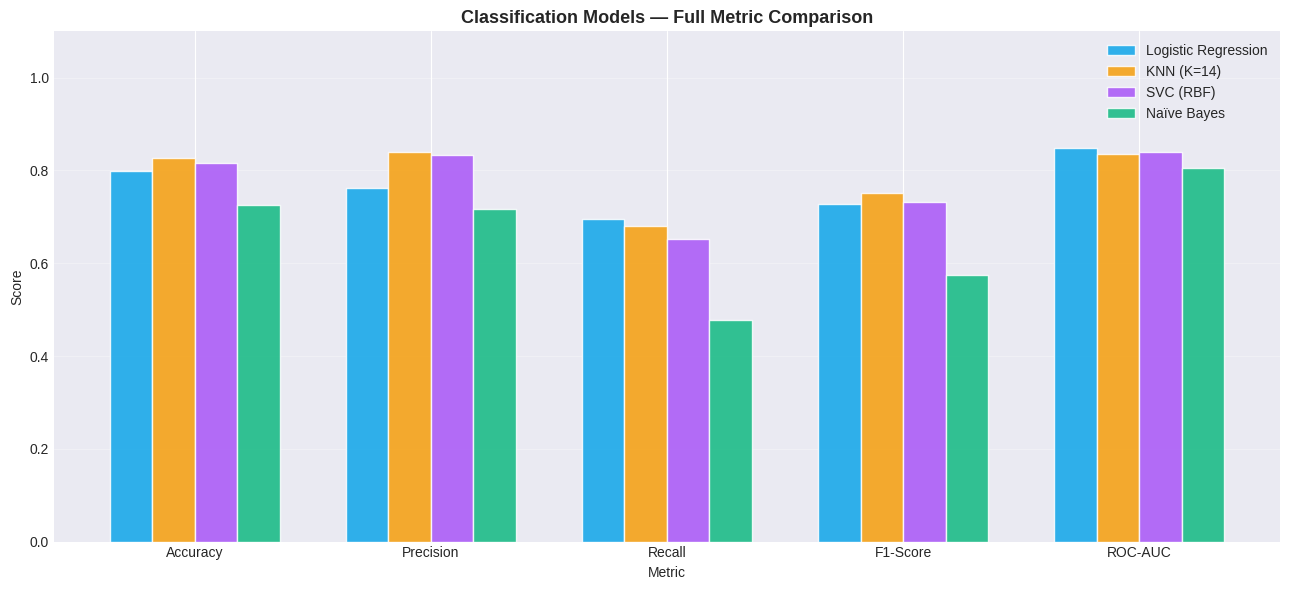

In [24]:
# ── Bar chart comparison ──────────────────────────────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.18
colors_bar = ['#0EA5E9', '#F59E0B', '#A855F7', '#10B981']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (name, row) in enumerate(results_df.iterrows()):
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, [row[m] for m in metrics], width,
                  label=name, color=colors_bar[i], alpha=0.85, edgecolor='white')

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Classification Models — Full Metric Comparison', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
# ── Full Classification Report for the best model ─────────────────────────────
best_model_name = results_df['F1-Score'].idxmax()
best_preds = dict(zip(
    [name for name, _, _ in all_models],
    [preds for _, preds, _ in all_models]
))[best_model_name]

print(f'🏆 Best Model by F1-Score: {best_model_name}')
print('\nDetailed Classification Report:')
print(classification_report(y_test, best_preds, target_names=['Did Not Survive', 'Survived']))

🏆 Best Model by F1-Score: KNN (K=14)

Detailed Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.82      0.92      0.87       110
       Survived       0.84      0.68      0.75        69

       accuracy                           0.83       179
      macro avg       0.83      0.80      0.81       179
   weighted avg       0.83      0.83      0.82       179



## 🔍 Step 8: Cross-Validation Deep Dive

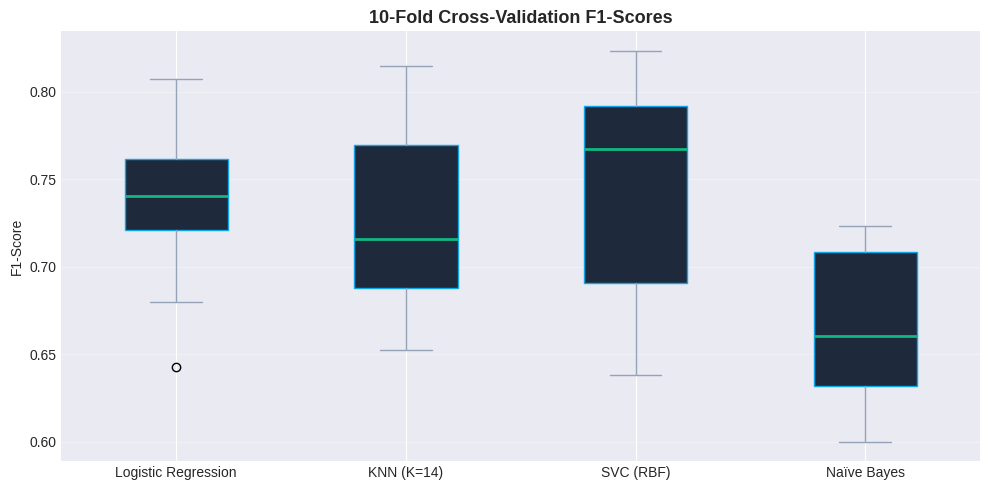

CV Results Summary:
  Logistic Regression       Mean: 0.7366  Std: 0.0468
  KNN (K=14)                Mean: 0.7255  Std: 0.0547
  SVC (RBF)                 Mean: 0.7437  Std: 0.0661
  Naïve Bayes               Mean: 0.6666  Std: 0.0441


In [26]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

estimators = [
    ('Logistic Regression', LogisticRegression(max_iter=500, random_state=42)),
    (f'KNN (K={best_k})',   KNeighborsClassifier(n_neighbors=best_k)),
    ('SVC (RBF)',           SVC(kernel='rbf', probability=True, random_state=42)),
    ('Naïve Bayes',         GaussianNB()),
]

cv_results = {}
for name, est in estimators:
    scores = cross_val_score(est, X_train_sc, y_train, cv=skf, scoring='f1')
    cv_results[name] = scores

# Boxplot of CV scores
plt.figure(figsize=(10, 5))
plt.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True,
            boxprops=dict(facecolor='#1E293B', color='#0EA5E9'),
            medianprops=dict(color='#10B981', linewidth=2),
            whiskerprops=dict(color='#94A3B8'),
            capprops=dict(color='#94A3B8'),
            flierprops=dict(marker='o', color='#F59E0B', markersize=6))
plt.title('10-Fold Cross-Validation F1-Scores', fontsize=13, fontweight='bold')
plt.ylabel('F1-Score')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('CV Results Summary:')
for name, scores in cv_results.items():
    print(f'  {name:<25} Mean: {scores.mean():.4f}  Std: {scores.std():.4f}')

## 🔮 Step 9: Making Predictions on New Passengers

In [27]:
# Use the best model to predict on new hypothetical passengers
best_estimator = dict(estimators)[best_model_name]
best_estimator.fit(X_train_sc, y_train)  # fit on full training data

# New passengers: [pclass, sex_encoded, age, fare, family_size, is_alone,
#                  fare_per_person, age_group_enc, emb_C, emb_Q, emb_S]
new_passengers = pd.DataFrame([
    # 1st class woman, age 30, paid high fare, alone
    [1, 0, 30, 150, 1, 1, 150,  2, 0, 0, 1],
    # 3rd class man, age 25, cheap ticket, family of 3
    [3, 1, 25,  8,  3, 0, 2.7, 2, 0, 0, 1],
    # 2nd class child, age 8, with family
    [2, 1,  8, 30,  4, 0, 7.5, 0, 1, 0, 0],
    # 1st class man, age 45, expensive ticket, alone
    [1, 1, 45, 200, 1, 1, 200, 3, 0, 0, 1],
], columns=features)

new_sc = scaler.transform(new_passengers)
predictions = best_estimator.predict(new_sc)

if hasattr(best_estimator, 'predict_proba'):
    probabilities = best_estimator.predict_proba(new_sc)[:, 1]
else:
    probabilities = [None] * len(predictions)

passenger_labels = [
    '1st Class Woman, 30, Solo',
    '3rd Class Man, 25, Family',
    '2nd Class Boy, 8, Family',
    '1st Class Man, 45, Solo',
]

print(f'\nPredictions using: {best_model_name}')
print('─' * 60)
for passenger, pred, prob in zip(passenger_labels, predictions, probabilities):
    status = '✅ SURVIVED' if pred == 1 else '❌ DID NOT SURVIVE'
    prob_str = f'(P={prob:.1%})' if prob is not None else ''
    print(f'{passenger:<35} → {status} {prob_str}')


Predictions using: KNN (K=14)
────────────────────────────────────────────────────────────
1st Class Woman, 30, Solo           → ✅ SURVIVED (P=85.7%)
3rd Class Man, 25, Family           → ❌ DID NOT SURVIVE (P=14.3%)
2nd Class Boy, 8, Family            → ✅ SURVIVED (P=78.6%)
1st Class Man, 45, Solo             → ✅ SURVIVED (P=71.4%)


## 📝 Step 10: Summary & Conclusions

In [28]:
print('=' * 65)
print('       WEEK 4 — CLASSIFICATION PROJECT SUMMARY')
print('=' * 65)
print()
print('Dataset: Titanic (891 passengers, 11 features after engineering)')
print('Target:  Survived (1) or Not (0) — Binary Classification')
print()
print('─' * 65)
print('MODEL PERFORMANCE (Test Set):')
print('─' * 65)
print(results_df[['Accuracy', 'F1-Score', 'ROC-AUC']].to_string())
print()
print('─' * 65)
print('KEY FINDINGS:')
print('─' * 65)

best_f1 = results_df['F1-Score'].idxmax()
best_auc = results_df['ROC-AUC'].idxmax()

print(f'  🏆 Best F1-Score:  {best_f1}')
print(f'  🥇 Best ROC-AUC:   {best_auc}')
print()
print('  📌 Most important features:')
print('     sex_encoded  → Women had much higher survival rates')
print('     pclass       → 1st class passengers survived more')
print('     fare         → Higher fare correlated with survival')
print()
print('  📌 Algorithm Insights:')
print('     • Logistic Regression: Fast, interpretable, good baseline')
print(f'    • KNN (K={best_k}): Non-parametric, no training, slow inference')
print('     • SVC: High accuracy, needs tuning, slow for large data')
print('     • Naïve Bayes: Fastest, assumes feature independence')
print('=' * 65)

       WEEK 4 — CLASSIFICATION PROJECT SUMMARY

Dataset: Titanic (891 passengers, 11 features after engineering)
Target:  Survived (1) or Not (0) — Binary Classification

─────────────────────────────────────────────────────────────────
MODEL PERFORMANCE (Test Set):
─────────────────────────────────────────────────────────────────
                     Accuracy  F1-Score  ROC-AUC
Model                                           
Logistic Regression    0.7989    0.7273   0.8491
KNN (K=14)             0.8268    0.7520   0.8362
SVC (RBF)              0.8156    0.7317   0.8404
Naïve Bayes            0.7263    0.5739   0.8059

─────────────────────────────────────────────────────────────────
KEY FINDINGS:
─────────────────────────────────────────────────────────────────
  🏆 Best F1-Score:  KNN (K=14)
  🥇 Best ROC-AUC:   Logistic Regression

  📌 Most important features:
     sex_encoded  → Women had much higher survival rates
     pclass       → 1st class passengers survived more
     fare    